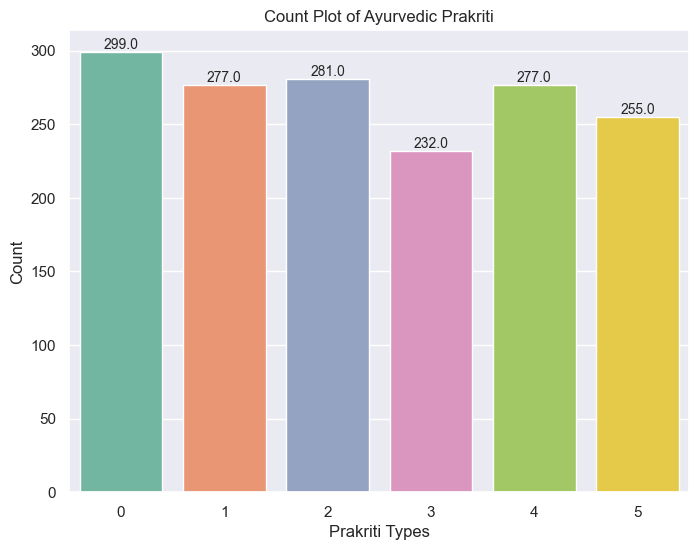

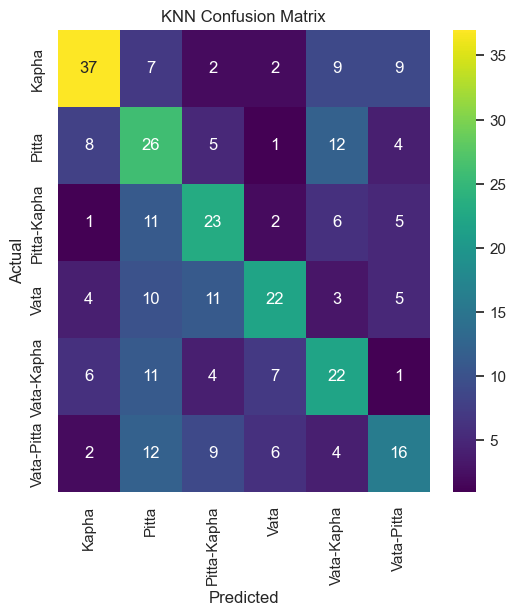

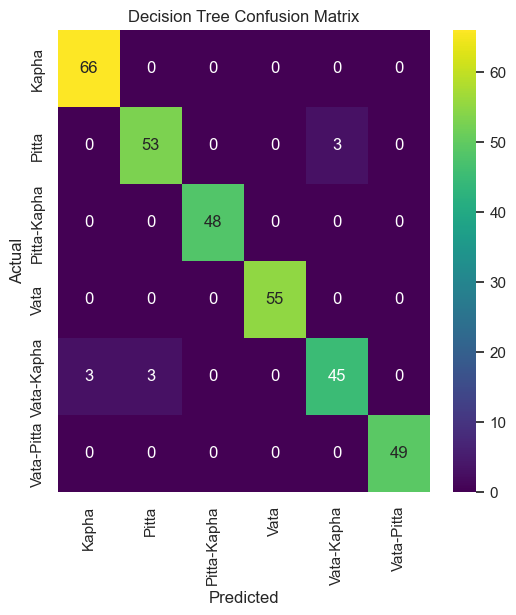

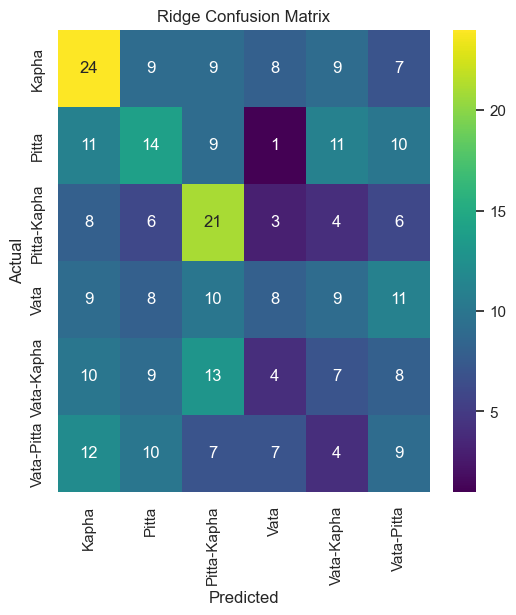

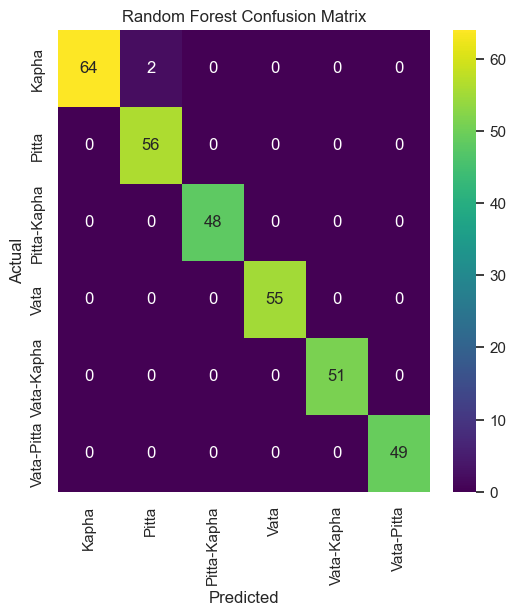

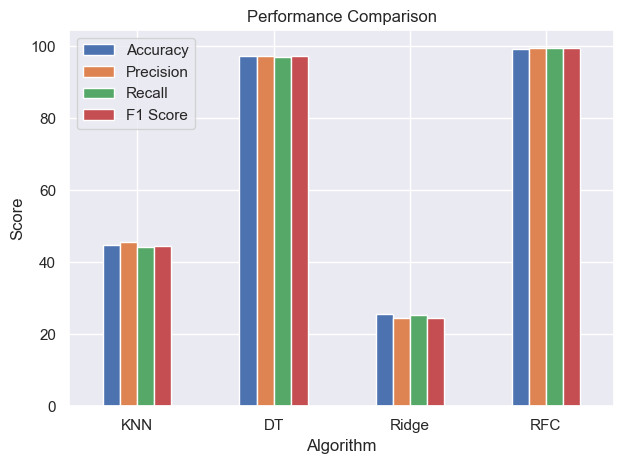

In [4]:
from tkinter import *
from tkinter import filedialog
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import joblib
import os

accuracy = []
precision = []
recall = []
fscore = []

target_name = 'prakriti'

labels = []
le_dict = {}
le_target = None

model_folder = "model"


def uploadDataset():
    global dataset

    filename = filedialog.askopenfilename(initialdir="Dataset")

    text.delete('1.0', END)
    text.insert(END, filename + ' Loaded\n\n')

    dataset = pd.read_csv(filename)

    text.insert(END, str(dataset.head()) + "\n\n")


def Preprocess_Dataset():
    global dataset, X, y, labels, le_dict, le_target

    text.delete('1.0', END)

    dataset = dataset.dropna()

    text.insert(END, str(dataset.isnull().sum()) + "\n\n")

    non_numeric = dataset.select_dtypes(exclude=['int', 'float']).columns

    le_dict = {}

    for col in non_numeric:
        if col != target_name:
            le = LabelEncoder()
            dataset[col] = le.fit_transform(dataset[col])
            le_dict[col] = le

    le_target = LabelEncoder()
    dataset[target_name] = le_target.fit_transform(dataset[target_name])

    labels = list(le_target.classes_)

    y = dataset[target_name]
    X = dataset.drop(target_name, axis=1)

    sns.set(style="darkgrid")
    plt.figure(figsize=(8, 6))

    ax = sns.countplot(
        x=target_name,
        data=dataset,
        hue=target_name,
        palette="Set2",
        legend=False
    )

    plt.title("Count Plot of Ayurvedic Prakriti")
    plt.xlabel("Prakriti Types")
    plt.ylabel("Count")

    for p in ax.patches:
        ax.annotate(
            f'{p.get_height()}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            fontsize=10,
            xytext=(0, 5),
            textcoords='offset points'
        )

    plt.show()

    text.insert(END, "Preprocessing Completed\n\n")


def Train_Test_Splitting():
    global X, y, x_train, x_test, y_train, y_test

    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0
    )

    text.delete('1.0', END)

    text.insert(END, f"Total Records: {X.shape[0]}\n")
    text.insert(END, f"Training: {x_train.shape[0]}\n")
    text.insert(END, f"Testing: {x_test.shape[0]}\n\n")


def Calculate_Metrics(name, predict, y_test):

    a = accuracy_score(y_test, predict) * 100
    p = precision_score(y_test, predict, average='macro') * 100
    r = recall_score(y_test, predict, average='macro') * 100
    f = f1_score(y_test, predict, average='macro') * 100

    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)

    text.insert(END, f"{name} Accuracy  : {a:.2f}%\n")
    text.insert(END, f"{name} Precision : {p:.2f}%\n")
    text.insert(END, f"{name} Recall    : {r:.2f}%\n")
    text.insert(END, f"{name} F1 Score  : {f:.2f}%\n\n")

    cm = confusion_matrix(y_test, predict)

    text.insert(END, f"{name} Confusion Matrix\n{cm}\n\n")

    CR = classification_report(y_test, predict, target_names=labels)

    text.insert(END, f"{name} Classification Report\n{CR}\n\n")

    plt.figure(figsize=(6, 6))

    sns.heatmap(
        cm,
        xticklabels=labels,
        yticklabels=labels,
        annot=True,
        fmt="g",
        cmap="viridis"
    )

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


def existing_classifiers():
    global x_train, y_train, x_test, y_test

    text.delete('1.0', END)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(x_train, y_train)
    pred_knn = knn.predict(x_test)
    Calculate_Metrics("KNN", pred_knn, y_test)

    dt = DecisionTreeClassifier()
    dt.fit(x_train, y_train)
    pred_dt = dt.predict(x_test)
    Calculate_Metrics("Decision Tree", pred_dt, y_test)

    ridge = RidgeClassifier()
    ridge.fit(x_train, y_train)
    pred_ridge = ridge.predict(x_test)
    Calculate_Metrics("Ridge", pred_ridge, y_test)


def proposed_classifier():
    global mlmodel

    text.delete('1.0', END)

    if not os.path.exists(model_folder):
        os.makedirs(model_folder)

    model_path = os.path.join(model_folder, "RFC_model.pkl")

    if os.path.exists(model_path):
        mlmodel = joblib.load(model_path)

    else:
        mlmodel = RandomForestClassifier()
        mlmodel.fit(x_train, y_train)
        joblib.dump(mlmodel, model_path)

    pred = mlmodel.predict(x_test)

    Calculate_Metrics("Random Forest", pred, y_test)


def Prediction():
    global mlmodel, X, le_dict, le_target

    text.delete('1.0', END)

    test_file = filedialog.askopenfilename(
        title="Select Test CSV",
        filetypes=[("CSV files", "*.csv")]
    )

    if not test_file:
        text.insert(END, "No file selected\n")
        return

    test_data = pd.read_csv(test_file)

    for col in le_dict:
        if col in test_data.columns:
            test_data[col] = pd.Categorical(
                test_data[col],
                categories=le_dict[col].classes_
            ).codes

    X_test = test_data.reindex(columns=X.columns, fill_value=0)

    if X_test.shape[0] == 0:
        text.insert(END, "No data found\n")
        return

    pred = mlmodel.predict(X_test)

    text.insert(END, "Predicted Prakriti:\n\n")

    for i, p in enumerate(pred):
        label = le_target.inverse_transform([p])[0]
        text.insert(END, f"Row {i+1} - {label}\n")


def graph():

    df = pd.DataFrame({
        "Algorithm": ["KNN", "DT", "Ridge", "RFC"],
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": fscore
    })

    df.set_index("Algorithm").plot(kind="bar")

    plt.title("Performance Comparison")
    plt.ylabel("Score")
    plt.xticks(rotation=0)
    plt.tight_layout()

    plt.show()


def close():
    main.destroy()


main = Tk()

main.geometry("1400x750")
main.title("Ayurvedic Prakriti Classification")

font = ('times', 16, 'bold')

title = Label(
    main,
    text='Ayurvedic Prakriti Classification',
    bg='gold2',
    fg='black',
    font=font,
    height=2,
    width=100
)

title.place(x=0, y=0)

btn_font = ('times', 12, 'bold')

Button(main, text="Dataset", command=uploadDataset, font=btn_font).place(x=20, y=100)
Button(main, text="Preprocessing", command=Preprocess_Dataset, font=btn_font).place(x=20, y=150)
Button(main, text="Train Test Split", command=Train_Test_Splitting, font=btn_font).place(x=20, y=200)
Button(main, text="Existing Classifiers", command=existing_classifiers, font=btn_font).place(x=20, y=250)
Button(main, text="Proposed Classifier", command=proposed_classifier, font=btn_font).place(x=20, y=300)
Button(main, text="Prediction", command=Prediction, font=btn_font).place(x=20, y=350)
Button(main, text="Comparison Graph", command=graph, font=btn_font).place(x=20, y=400)
Button(main, text="Exit", command=close, font=btn_font).place(x=20, y=450)

font1 = ('times', 12)

text = Text(main, height=30, width=95, font=font1)
text.place(x=300, y=100)

scroll = Scrollbar(main, command=text.yview)
scroll.place(x=1180, y=100, height=500)

text.config(yscrollcommand=scroll.set)

main.config(bg='LightSteelBlue1')

main.mainloop()
